## Figure 1 Generation

### The goal of this notebook is to produce a plot for Figure 1. 

General Schema:

For a given climate variable, say, tas, plot its global average value over time from 2015 to 2100, 1 thin line per each ensemble per model and one thick line per average of all models, for both a non net-zero scenario and a net-zero scenario.

Indicate approximate years of net-zero accomplishment in both scenarios.

Label accordingly.

### Imports and File Stitching

In [1]:
# Imports
import os
import re
import numpy as np
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# ----File Stitching----
# If in prep folder, cd back to base repository folder
if os.path.basename(os.getcwd()) == "prep":
    os.chdir('../..')

# Control which user's files are accessed
match_sk = 'sophiekim'
match_hc = 'hayeonchung'
match_ck = 'Caroline'
match_st = 'student'
path_str = os.getcwd()
print(path_str)
if re.search(match_sk, path_str):
    os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
    user = match_sk
    print("Sophie Kim recognized as user.")
elif re.search(match_hc, path_str):
    os.chdir("/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch") 
    user = match_hc
    print("Hayeon Chung recognized as user.")
elif re.search(match_ck, path_str):
    os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
    user = 'carolinekranefuss'
    print("Caroline Kranefuss recognized as user.")
elif re.search(match_st, path_str):
    os.chdir("/Users/student/Desktop/mamalakis_research/MamalakisResearch")
    user = match_st
    print("Student recognized as user.")
else:
    print("User not recognized. Please manually change directory.")

c:\Users\student\Desktop\mamalakis_research\MamalakisResearch
Student recognized as user.


In [2]:
# Assign base path
base_path = os.getcwd()

# All users should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [3]:
# initializing model list variable to call in function
model_list = [
    "CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
]

model_paths = [data_path + model for model in model_list]

model_paths

['c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc']

In [4]:
def convert_units(varname: str, x: np.ndarray):
    """
    varname: index number from the list of variables so get_data func can convert units 
    x: data that needs units changed (raw x data) in get_data func 
    """
    if varname in {"tas", "tasmax", "tasmin"}:
        # kelvin to celsius
        return x - 273.15, "$^{\circ}$C"
    if varname == "pr":
        # kg/(m2*s) to mm/day
            # 1kg/m2 = 1 mm 
        return x * 86400.0, "mm/day"
    if varname == "psl":
        # pascals to hpa
        return x / 100.0, "hPa"
    
    # these don't need to be converted -- just adding the units 
    if varname == "sfcWind":
        return x, "m/s"
    if varname == "mrsos":
        return x, "kg/m$^{2}$"
    return x, "unknown"

In [5]:
# Define global variable for script
var = 'tas'

In [15]:
def var_yr_avgs(model, scenario='ssp119', var=var):
    """
    A function to obtain the average global value of a variable year by year for a given scenario and model for each ensemble of that model
    Default is ssp119
    Returns: An array of floats
    """

    # Define order of variables in data loaded to obtain index
    var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]
    for i, item in enumerate(var_list):
        if re.match(item, var):
            var_index = i

    # Months range from 1 to 1032 but numpy is zero-indexed, so 0 to 1031 
    months = np.arange(0,1032,1)   

    # Make an array for each ensemble, 5 ensembles per model 
    ensembles = [[],[],[],[],[]]

    # loading the data for specific model 
    with nc.Dataset(model) as ds:

        # For each ensemble, 
        for i, ens in enumerate(ensembles):
            
            # Take the average of all global values for the variable per month and append to the appropriate ensembles array
            for month in months:

                # Slice dimensions for the ensemble, the specific var index and all the lon/lat dimensions for EACH month; then find average of all global values for that month
                vals_mth_ensemble = ds[f"data_{scenario}"][i, var_index, month, :, :] 

                # Take the mean of the var_index values
                global_avg_ens_mth = np.nanmean(vals_mth_ensemble[1])

                ensembles[i].append(global_avg_ens_mth)
    # Now we have an list of lists - average global variable values for every month, repeated across each ensemble of a model

    # Convert to yearly averages
    ensembles_yr = [] 
    for ensemble in ensembles:
        # Convert to array 
        ensemble_arr = np.array(ensemble)
        # Reshape
        yearly_ens = np.mean(ensemble_arr.reshape((len(ensemble_arr)//12,12)),axis=1) 
        # Do unit conversion 
        units_changed, _ = convert_units(var, yearly_ens)
        # Assign
        ensembles_yr.append(units_changed)

    return ensembles_yr

print(len(var_yr_avgs(model_paths[0])[0])) # Sanity check: Confirmed to contain 86 years

print(var_yr_avgs(model_paths[0])) # Sanity check: does 4.7 degrees Celsius make sense for a January temperature?
                                   # About 40 degrees Fahrenheit, there are 2 poles (cold) but only one equator (hot)

# Run function for SSP119
all_model_results_119 = []
for model in model_paths:
    all_model_results_119.append(var_yr_avgs(model))

# Run functon for SSP126
all_model_results_126 = []
for model in model_paths:
    all_model_results_126.append(var_yr_avgs(model, "ssp126"))

print("Done!")

86
[array([4.70522149, 4.87972383, 5.3211412 , 4.86999626, 4.52488589,
       5.93984738, 4.75484774, 4.89330985, 4.70993875, 4.74664875,
       5.03058508, 5.3151815 , 5.04672202, 5.35015864, 5.33541661,
       4.76161755, 5.04725057, 5.4307184 , 5.06604566, 5.68742158,
       5.21483668, 5.21760406, 5.18127224, 5.37645437, 5.33853977,
       5.62909469, 5.52626623, 4.9001978 , 5.11487984, 5.00885103,
       5.47347856, 5.53839144, 5.67033476, 5.09008364, 5.43370348,
       5.69527316, 5.51735337, 5.38401239, 4.80336112, 5.60961153,
       5.42999217, 5.52737011, 5.46661718, 5.20852702, 5.45895003,
       5.08296363, 5.70233547, 4.78553493, 5.56470787, 6.07104566,
       5.84134459, 5.13016397, 5.83135475, 4.93007808, 5.5727716 ,
       5.46931107, 5.5665233 , 5.33906362, 5.12680029, 4.9163237 ,
       5.98171154, 5.85009501, 5.88282604, 5.48262386, 5.53243861,
       5.77736733, 5.76201021, 5.79261489, 5.25136417, 5.31638251,
       4.82526974, 5.11976349, 5.43825824, 5.42881029, 6.1

**meeting notes 06/01:**

- each point = global annual avg per variable for each trajectory within the model 
    - so 5 time series and using standardized values from the trajectories 
- standardize by getting avg of baseline time period (should be 50 pts) and then subtract the baseline from each point 
    - (global annual avg - mean from 2015-2024) / std from 2015-2024
    - do this separately for each model --> bc each model might have diff avgs and stds 
        - and separately for each scenario 

- standardization should be done under each trajectory and under each model 


simplified version of time series for figure 1A 

I need to combine each ensemble into a single model at the very end or not at all and do calculations incl std FIRST

In [16]:
def conversion(model_var_over_time):
    """
    A function to convert raw temperatures to deviations
    Output: Array of floats
    """

    # Baseline is the average of the first decade
    baseline = np.mean(model_var_over_time[0:10])

    # Calculate the standard deviation of the baseline
    std = np.std(baseline)

    diff_over_time = model_var_over_time - baseline
    # Wait what do we do if std is zero do we do the quantile thing here too 
    # For now just don't divide MUST FIX
    if std != 0:
        final = diff_over_time / std
    else:
        final = diff_over_time

    return final

# Run function for SSP119
# Array to hold all model results
all_diff_results_119 = []
for model in all_model_results_119:
    # Array to hold ensemble results
    all_ens = []
    for ensemble in model:
        all_ens.append(conversion(ensemble))
    # Then append each list to bigger array
    all_diff_results_119.append(all_ens)

# Run function for SSP126
# Array to hold all model results
all_diff_results_126 = []
for model in all_model_results_126:
    # Array to hold ensemble results
    all_ens = []
    for ensemble in model:
        all_ens.append(conversion(ensemble))
    # Then append each list to bigger array
    all_diff_results_126.append(all_ens)


print("Done!")

Done!


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

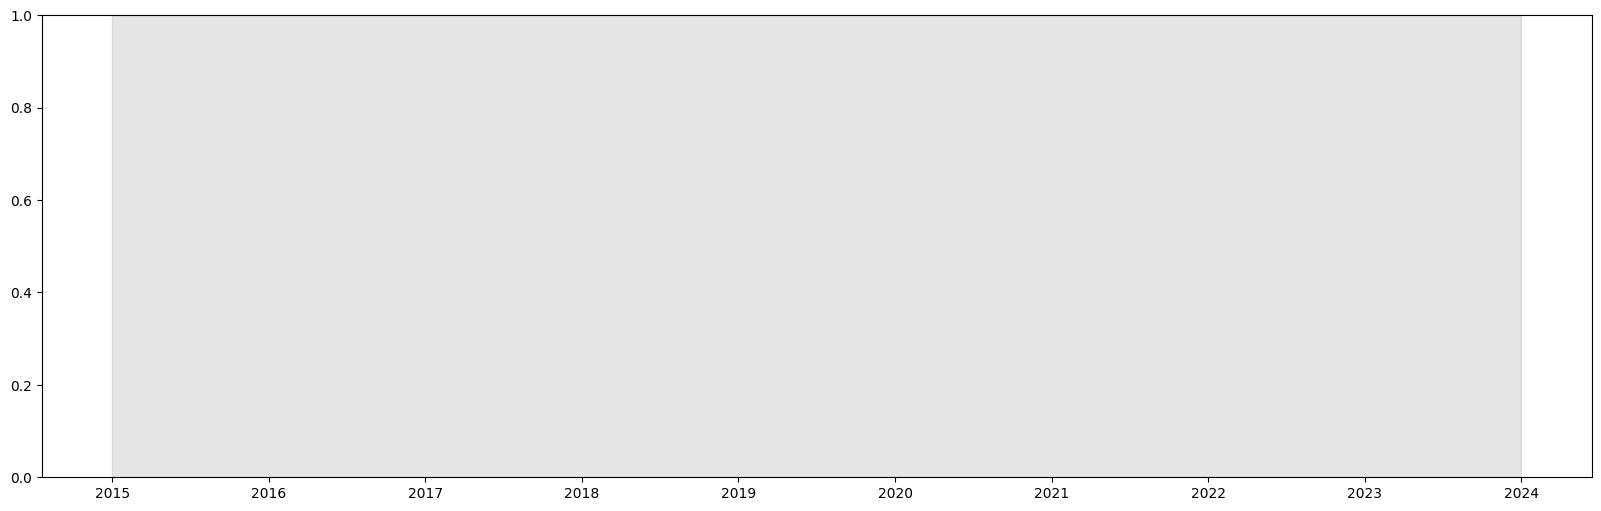

In [24]:
def time_series_plot(results_119, results_126):

    # Transpose so dimensions match
    results_119 = np.array(results_119).T
    results_126 = np.array(results_126).T

   # Create a range for the x-axis (time)
    yrs = np.arange(2015, 2101, 1) 
    
    # Check variables and obtain y-axis label
    if var == 'tas':
        y = 'Mean Surface Temperature ($^{\circ}$C)'
    elif var == 'tasmax':
        y = 'Max Surface Temperature ($^{\circ}$C)'
    elif var == 'tasmin':
        y = 'Min Surface Temperature ($^{\circ}$C)'
    elif var == 'pr':
        y = 'Precipitation (mm/day)'
    elif var == 'psl':
        y = 'Pressure at Sea Level (hPa)'
    elif var == 'sfcWind':
        y = 'Surface Wind Speed (m/s)'
    elif var == 'mrsos':
        y = 'Moisture in Upper Soil Column (kg/m$^{2}$)'
    else:
        print('Variable must be tas, tasmax, tasmin, pr, psl, sfcWind, or mrsos.')
        return

    # Set up plot 
    fig, ax = plt.subplots(figsize=(20, 6))
    plt.locator_params(axis='x', nbins=10)

    # Create a box for baseline climate
    ax.axvspan(2015, 2024, color='grey', alpha=0.2, zorder=0, label='Baseline Climate (2015-2024)')


    # Get average of each model's ensembles
    model_averages_119 = []
    for item in results_119:
        model_avg = [np.mean(k) for k in zip(*item)] if item else None # Safeguard if one scenario missing
        model_averages_119.append(model_avg)
    # Get average of models
    average_119 = [np.mean(k) for k in zip(*model_averages_119)] if model_averages_119 else None

    # Repeat for SSP126
    model_averages_126 = []
    for item in results_119:
        model_avg = [np.mean(k) for k in zip(*item)] if item else None # Safeguard if one scenario missing
        model_averages_126.append(model_avg)
    # Get average of models
    average_126 = [np.mean(k) for k in zip(*model_averages_126)] if model_averages_126 else None


    # Plot values
    for i, ensemble in enumerate(results_119):
        plt.plot(yrs, ensemble, color='#8cc5e3', linewidth=1, alpha=0.5)
        # Create legend for only one ensemble line
        if i == 0:
            plt.plot(yrs, results_119[0], label='SSP1-1.9 Model Ensembles', color='#8cc5e3', linewidth=1, alpha=0.5)
    li119 = ax.plot(yrs, average_119, label='Average: All Models in SSP1-1.9', color='#8cc5e3', linewidth=2)

    # Repeat for SSP126
    for i, ensemble in enumerate(results_126):
        plt.plot(yrs, ensemble, color='#8cc5e3', linewidth=1, alpha=0.5)
        # Create legend for only one ensemble line
        if i == 0:
            plt.plot(yrs, results_126[0], label='SSP1-2.6 Model Ensembles', color='#8cc5e3', linewidth=1, alpha=0.5)
    li126 = ax.plot(yrs, average_126, label='Average: All Models in SSP1-2.6', color='#8cc5e3', linewidth=2)


    # Plot net-zero lines

    # Find the index for the years 2050 and 2070 and 2026 in the 'yrs' array
    idx_2050 = np.where(yrs == 2050)[0][0]
    idx_2070 = np.where(yrs == 2070)[0][0]
    idx_2026 = np.where(yrs == 2026)[0][0]
    
    # Extract the exact y-values at those years from the average arrays
    y_2050 = average_119[idx_2050]
    y_2070 = average_126[idx_2070]
    # Plot current year at mean between ssp119 and ssp126 heights
    y_2026 = (average_119[idx_2026] + average_126[idx_2026])/2


    # Current y-axis limits (lines start at bottom)
    ymin, ymax = ax.get_ylim()


    # Use vlines to plot using data coordinates (x, ymin, ymax)
    plt.vlines(x=2050, ymin=ymin, ymax=y_2050, color='#0d7d87', label='Net Zero ~2050 (SSP1-1.9)')
    plt.vlines(x=2070, ymin=ymin, ymax=y_2070, color='#4a2377', label='Net Zero ~2070 (SSP1-2.6)')
    plt.vlines(x=2026, ymin=ymin, ymax=y_2026, color="#AAAAAA", label='Current Year')
    
    # Re-set ymin, ymax to not extend bottom of graph
    ax.set_ylim(ymin, ymax)

    # Formatting
    plt.xlabel("Year")
    plt.ylabel(f"{y} Deviation (Global Annual Mean)")
    plt.legend()
    plt.title(f"{y} Deviation, Global Annual Mean 2015 to 2100")
     # Move legend
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    # Make room for the right-side legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.5)
    

    plt.show()

time_series_plot(all_diff_results_119, all_diff_results_126)

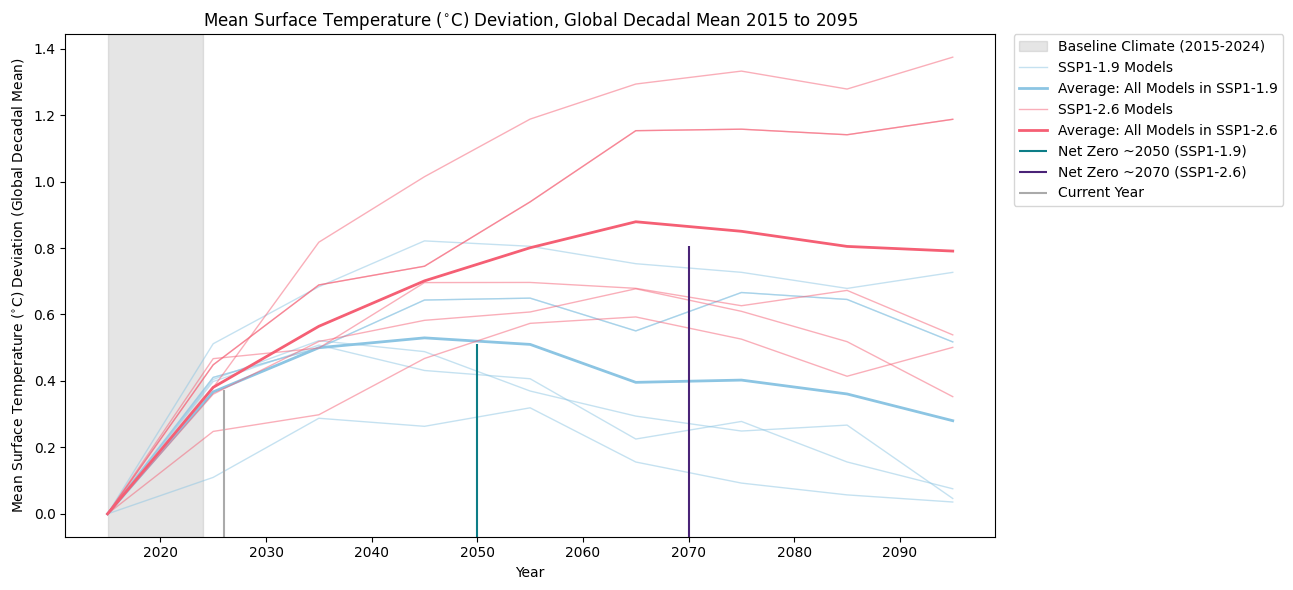

In [ ]:
time_series_plot(simple='yes')